# Tests sur les MLP

### Pytorch tests

In [1]:
import torch
print(torch.cuda.is_available())

True


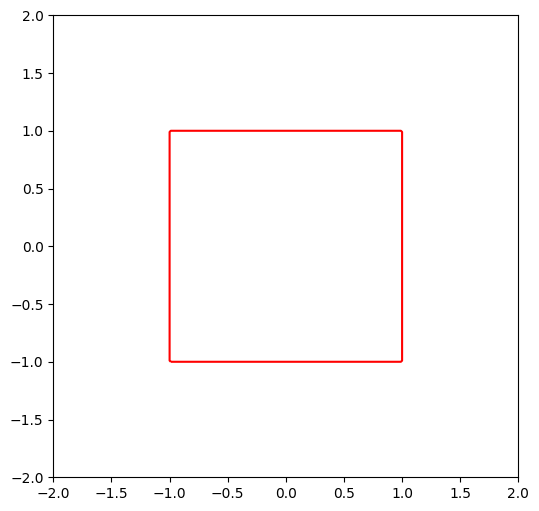

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def circle(x,y,r) : return x**2 + y**2 -r**2

def square(x,y,r) : return np.maximum(np.abs(x)-r, np.abs(y)-r)

gridx = np.linspace(-2,2,100)
gridy = np.linspace(-2,2,100)
X,Y = np.meshgrid(gridx,gridy)

Z = square(X,Y,1)

plt.figure(figsize=(6,6))

plt.contour(X,Y,Z,levels=[0], colors='red')
plt.show()

## Basic MLP

In [15]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(2, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    
    def forward(self,x):
        return self.layers(x)

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_sdf(model, sdf_func, nb_samples, lr, nb_epochs, loss_type='mse'):
    #between -2 and 2
    x = (torch.randn(nb_samples,2)*4) - 2
    y = sdf_func(x[:,0], x[:,1], 1)

    model = model.to(device)
    criterion = nn.MSELoss() if loss_type == 'mse' else nn.L1Loss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    x = x.to(device)
    y = y.to(device)

    for epoch in range(nb_epochs):
        optimizer.zero_grad()
        output = model(x).squeeze()
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item()}")
    return model

In [ ]:
mlp = train_sdf(MLP(), square, 100000, 0.001, 20000, 'mse')

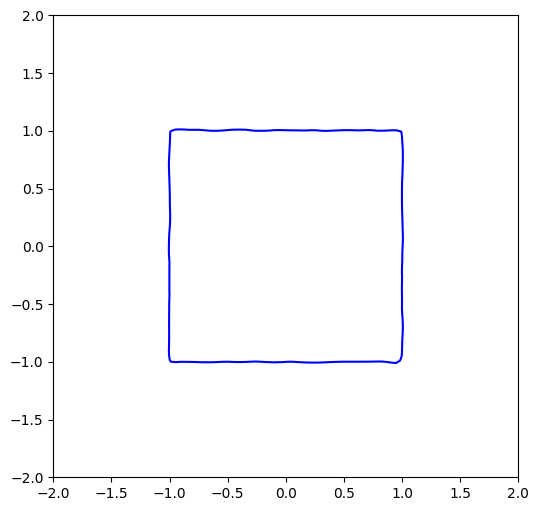

In [22]:
with torch.no_grad():
    gridx = torch.linspace(-2,2,100)
    gridy = torch.linspace(-2,2,100)
    X,Y = torch.meshgrid(gridx,gridy)
    X = X.to(device)
    Y = Y.to(device)
    Z = mlp(torch.stack([X.flatten(), Y.flatten()], dim=1)).reshape(X.shape)

    X = X.cpu().numpy()
    Y = Y.cpu().numpy()
    Z = Z.cpu().numpy()

plt.figure(figsize=(6,6))
plt.contour(X,Y,Z,levels=[0], colors='blue')
plt.show()

## Positionnal encoding

In [50]:

def positional_encoding(x, num_frequencies):
    encoding = []
    for i in range(x.shape[-1]):
        xi = x[..., i:i+1] 
        encoding.append(xi) 
        frequencies = 2 ** torch.arange(num_frequencies, dtype=x.dtype, device=x.device)
        for freq in frequencies:
            encoding.append(torch.sin(freq * xi))
            encoding.append(torch.cos(freq * xi))
    return torch.cat(encoding, dim=-1)  


class SharpMLP(nn.Module):
    def __init__(self,num_frequencies=6):
        super().__init__()
        self.num_frequencies = num_frequencies
        input_size = 2 + 4 * num_frequencies
        self.layers = nn.Sequential(
            nn.Linear(input_size,256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )

    def forward(self,x):
        x_enc = positional_encoding(x, self.num_frequencies)
        return self.layers(x_enc)

In [ ]:
mlp_sharp = train_sdf(SharpMLP(12), square, 100000, 0.001, 20000, 'l1')

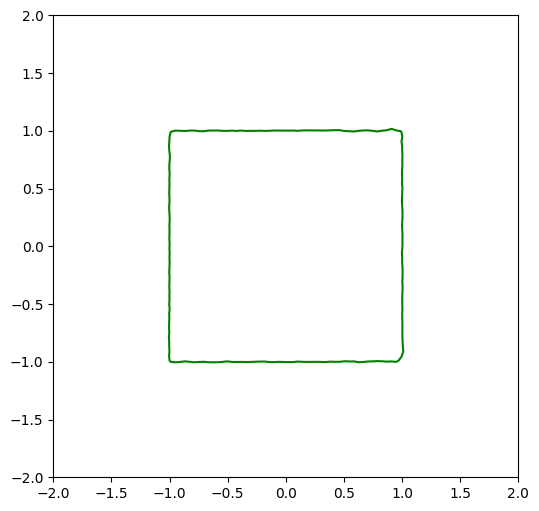

In [30]:
with torch.no_grad():
    gridx = torch.linspace(-2,2,100)
    gridy = torch.linspace(-2,2,100)
    X,Y = torch.meshgrid(gridx,gridy)
    X = X.to(device)
    Y = Y.to(device)
    Z = mlp(torch.stack([X.flatten(), Y.flatten()], dim=1)).squeeze().reshape(X.shape)
    X = X.cpu().numpy()
    Y = Y.cpu().numpy()
    Z = Z.cpu().numpy()

plt.figure(figsize=(6,6))
plt.contour(X,Y,Z,levels=[0], colors='green')
plt.show()    


## Adding high frequences

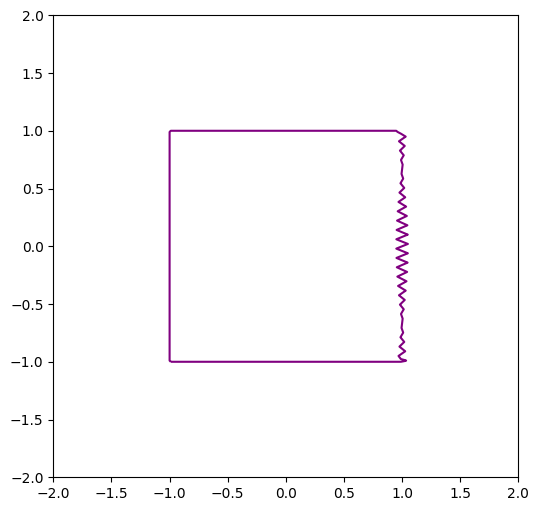

In [43]:
def hf_square(x,y,r,freq=24,amp=0.05) : 

    perturbation = amp * np.sin(freq * np.pi * y / r)
    
    # Right edge (x > 0) 
    right_side = np.where(x > 0, x - r - perturbation, -x - r)
    
    return np.maximum(right_side, np.abs(y) - r)

plt.figure(figsize=(6,6))
gridx = np.linspace(-2,2,100)
gridy = np.linspace(-2,2,100)
X,Y = np.meshgrid(gridx,gridy)
Z = hf_square(X,Y,1)
plt.contour(X,Y,Z,levels=[0], colors='purple')
plt.show()

In [52]:
# Train MLP on hf_square
mlp_hf = train_sdf(MLP, {}, hf_square, 100000, 0.001, 20000, 'mse')

/tmp/ipykernel_7094/2514287192.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  perturbation = amp * np.sin(freq * np.pi * y / r)
/tmp/ipykernel_7094/2514287192.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.maximum(right_side, np.abs(y) - r)


Epoch 0, Loss: 22.852249145507812
Epoch 100, Loss: 0.1428699642419815
Epoch 200, Loss: 0.0035919062793254852
Epoch 300, Loss: 0.0016463117208331823
Epoch 400, Loss: 0.0010521418880671263
Epoch 500, Loss: 0.0007770594675093889
Epoch 600, Loss: 0.0006232746527530253
Epoch 700, Loss: 0.0005109458579681814
Epoch 800, Loss: 0.00043463686597533524
Epoch 900, Loss: 0.00037854735273867846
Epoch 1000, Loss: 0.0003386173921171576
Epoch 1100, Loss: 0.0003084675408899784
Epoch 1200, Loss: 0.00040138285839930177
Epoch 1300, Loss: 0.0002668558154255152
Epoch 1400, Loss: 0.0002540907880757004
Epoch 1500, Loss: 0.0002405980631010607
Epoch 1600, Loss: 0.0002312996657565236
Epoch 1700, Loss: 0.00022347361664287746
Epoch 1800, Loss: 0.0002757878100965172
Epoch 1900, Loss: 0.00020985284936614335
Epoch 2000, Loss: 0.00020448076247703284
Epoch 2100, Loss: 0.00024550341186113656
Epoch 2200, Loss: 0.0001965336559806019
Epoch 2300, Loss: 0.00023682972823735327
Epoch 2400, Loss: 0.00019035428704228252
Epoch 250

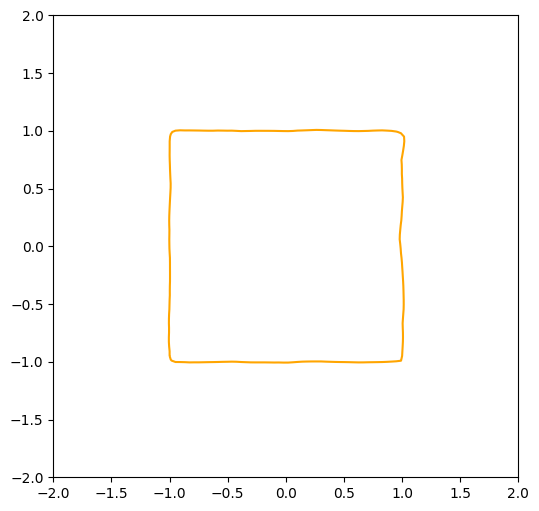

In [53]:
# Plot MLP trained on hf_square
with torch.no_grad():
    gridx = torch.linspace(-2,2,100)
    gridy = torch.linspace(-2,2,100)
    X,Y = torch.meshgrid(gridx,gridy)
    X = X.to(device)
    Y = Y.to(device)
    Z = mlp_hf(torch.stack([X.flatten(), Y.flatten()], dim=1)).reshape(X.shape)

    X = X.cpu().numpy()
    Y = Y.cpu().numpy()
    Z = Z.cpu().numpy()

plt.figure(figsize=(6,6))
plt.contour(X,Y,Z,levels=[0], colors='orange')
plt.show()

In [ ]:
# Train SharpMLP on hf_square
mlp_sharp_hf = train_sdf(SharpMLP(12), hf_square, 100000, 0.001, 20000, 'l1')

/tmp/ipykernel_7094/2514287192.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  perturbation = amp * np.sin(freq * np.pi * y / r)
/tmp/ipykernel_7094/2514287192.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.maximum(right_side, np.abs(y) - r)


Epoch 0, Loss: 4.11447286605835
Epoch 100, Loss: 0.0841151550412178
Epoch 200, Loss: 0.08829298615455627
Epoch 300, Loss: 0.0554441474378109
Epoch 400, Loss: 0.05810070037841797
Epoch 500, Loss: 0.047925036400556564
Epoch 600, Loss: 0.05105936527252197
Epoch 700, Loss: 0.04490618035197258
Epoch 800, Loss: 0.04691743850708008
Epoch 900, Loss: 0.04409659653902054
Epoch 1000, Loss: 0.04448866471648216
Epoch 1100, Loss: 0.04193393886089325
Epoch 1200, Loss: 0.04297676682472229
Epoch 1300, Loss: 0.040766000747680664
Epoch 1400, Loss: 0.04145035147666931
Epoch 1500, Loss: 0.03978274017572403
Epoch 1600, Loss: 0.04068724066019058
Epoch 1700, Loss: 0.03856576606631279
Epoch 1800, Loss: 0.03960031643509865
Epoch 1900, Loss: 0.038015201687812805
Epoch 2000, Loss: 0.03825000301003456
Epoch 2100, Loss: 0.03718199208378792
Epoch 2200, Loss: 0.037543196231126785
Epoch 2300, Loss: 0.03670620918273926
Epoch 2400, Loss: 0.03699025139212608
Epoch 2500, Loss: 0.03600650653243065
Epoch 2600, Loss: 0.03598

In [ ]:
# Plot SharpMLP trained on hf_square
with torch.no_grad():
    gridx = torch.linspace(-2,2,100)
    gridy = torch.linspace(-2,2,100)
    X,Y = torch.meshgrid(gridx,gridy)
    X = X.to(device)
    Y = Y.to(device)
    Z = mlp_sharp_hf(torch.stack([X.flatten(), Y.flatten()], dim=1)).squeeze().reshape(X.shape)
    X = X.cpu().numpy()
    Y = Y.cpu().numpy()
    Z = Z.cpu().numpy()

plt.figure(figsize=(6,6))
plt.contour(X,Y,Z,levels=[0], colors='red')
plt.show()